# Cox Proportional Hazards and Random Survival Forests

Welcome to the final assignment in Course 2! In this assignment you'll develop risk models using survival data and a combination of linear and non-linear techniques. We'll be using a dataset with survival data of patients with Primary Biliary Cirrhosis (pbc). PBC is a progressive disease of the liver caused by a buildup of bile within the liver (cholestasis) that results in damage to the small bile ducts that drain bile from the liver. Our goal will be to understand the effects of different factors on the survival times of the patients. Along the way you'll learn about the following topics: 

- Cox Proportional Hazards
  - Data Preprocessing for Cox Models.
- Random Survival Forests
  - Permutation Methods for Interpretation.

---
<a name='submission'></a>

<h4 style="color:green; font-weight:bold;">TIPS FOR SUCCESSFUL GRADING OF YOUR ASSIGNMENT:</h4>

* All cells are frozen except for the ones where you need to submit your solutions or when explicitly mentioned you can interact with it.

* In each exercise cell, look for comments `### START CODE HERE ###` and `### END CODE HERE ###`. These show you where to write the solution code. **Do not add or change any code that is outside these comments**.

* You can add new cells to experiment but these will be omitted by the grader, so don't rely on newly created cells to host your solution code, use the provided places for this.

* Avoid using global variables unless you absolutely have to. The grader tests your code in an isolated environment without running all cells from the top. As a result, global variables may be unavailable when scoring your submission. Global variables that are meant to be used will be defined in UPPERCASE.

* To submit your notebook for grading, first save it by clicking the 💾 icon on the top left of the page and then click on the `Submit assignment` button on the top right of the page.
---

## Table of Contents

- [1. Import Packages](#1)
- [2. Load the Dataset](#2)
- [3. Explore the Dataset](#3)
- [4. Cox Proportional Hazards](#4)
    - [Exercise 1 - to_one_hot](#ex-1)
- [5. Fitting and Interpreting a Cox Model](#5)
- [6. Hazard ratio](#3)
    - [Exercise 2 - hazard_ratio](#ex-2)
- [7. Harrell's C-Index](#7)
    - [Exercise 3 - harrell_c](#ex-3)
- [8. Random Survival Forests](#8)
- [9. Permutation Method for Interpretation](#9)

<a name='1'></a>
## 1. Import Packages

We'll first import all the packages that we need for this assignment. 

- `sklearn` is one of the most popular machine learning libraries.
- `numpy` is the fundamental package for scientific computing in python.
- `pandas` is what we'll use to manipulate our data.
- `matplotlib` is a plotting library.
- `lifelines` is an open-source survival analysis library.

In [ ]:
import sys
import warnings

# Redirect stderr to a black hole to catch other potential messages
class BlackHole:
    def write(self, message):
        pass
    def flush(self):
        pass
sys.stderr = BlackHole()

# Ignore Python-level UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from pprint import pprint
import sklearn
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index as cindex
from sklearn.model_selection import train_test_split

import helper_utils
import unittests

<a name='2'></a>
## 2. Load the Dataset

Run the next cell to load the data.

In [ ]:
df = helper_utils.load_data('data/pbc.csv')

<a name='3'></a>
## 3. Explore the Dataset

In the lecture videos `time` was in months, however in this assignment, `time` will be converted into years. Also notice that we have assigned a numeric value to `sex`, where `female = 0` and `male = 1`.

Next, familiarize yourself with the data and the shape of it. 

In [ ]:
print(df.shape)

# df.head() only outputs the top few rows
df.head()

Take a minute to examine particular cases.

In [ ]:
i = 20
df.iloc[i, :]

<br>
Now, split your dataset into train, validation and test set using 60/20/20 split. 

In [ ]:
np.random.seed(0)
df_dev, df_test = train_test_split(df, test_size = 0.2)
df_train, df_val = train_test_split(df_dev, test_size = 0.25)

print("Total number of patients:", df.shape[0])
print("Total number of patients in training set:", df_train.shape[0])
print("Total number of patients in validation set:", df_val.shape[0])
print("Total number of patients in test set:", df_test.shape[0])

<br>
Before proceeding to modeling, let's normalize the continuous covariates to make sure they're on the same scale. Again, we should normalize the test data using statistics from the train data.

In [ ]:
continuous_columns = ['age', 'bili', 'chol', 'albumin', 'copper', 'alk.phos', 'ast', 'trig', 'platelet', 'protime']
mean = df_train.loc[:, continuous_columns].mean()
std = df_train.loc[:, continuous_columns].std()
df_train.loc[:, continuous_columns] = (df_train.loc[:, continuous_columns] - mean) / std
df_val.loc[:, continuous_columns] = (df_val.loc[:, continuous_columns] - mean) / std
df_test.loc[:, continuous_columns] = (df_test.loc[:, continuous_columns] - mean) / std

Let's check the summary statistics on our training dataset to make sure it's standardized.

In [ ]:
df_train.loc[:, continuous_columns].describe()

<a name='4'></a>
## 4. Cox Proportional Hazards

Our goal is to build a risk score using the survival data that we have. We'll begin by fitting a Cox Proportional Hazards model to your data.

Recall that the Cox Proportional Hazards model describes the hazard for an individual $i$ at time $t$ as 

$$
\lambda(t, x) = \lambda_0(t)e^{\theta^T X_i}
$$

The $\lambda_0$ term is a baseline hazard and incorporates the risk over time, and the other term incorporates the risk due to the individual's covariates. After fitting the model, we can rank individuals using the person-dependent risk term $e^{\theta^T X_i}$. 

Categorical variables cannot be used in a regression model as they are. In order to use them, conversion to a series of variables is required.

Since our data has a mix of categorical (`stage`) and continuous (`wblc`) variables, before we proceed further we need to do some data engineering. To tackle the issue at hand we'll be using the `Dummy Coding` technique. In order to use Cox Proportional Hazards, we will have to turn the categorical data into one hot features so that we can fit our Cox model. Luckily, Pandas has a built-in function called `get_dummies` that will make it easier for us to implement our function. It turns categorical features into multiple binary features.

<img src="./nb_image/1-hot-encode.png" style="padding-top: 5px;width: 60%;left: 0px;margin-left: 150px;margin-right: 0px;">




<a name='ex-1'></a>
### Exercise 1 - to_one_hot
In the cell below, implement the `to_one_hot(...)` function.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints (Click to expand)</b></font>
</summary>
<p>
<ul>
    <li>Remember to drop the first dummy for each each category to avoid convergence issues when fitting the proportional hazards model.</li>
    <li> Check out the <a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html" > get_dummies() </a>  documentation. </li>
    <li>Use <code>dtype=np.float64</code>.</li>
</ul>
</p>

In [20]:
# GRADED FUNCTION: to_one_hot

def to_one_hot(dataframe, columns):
    '''
    Convert columns in dataframe to one-hot encoding.
    Args:
        dataframe (dataframe): pandas dataframe containing covariates
        columns (list of strings): list categorical column names to one hot encode
    Returns:
        one_hot_df (dataframe): dataframe with categorical columns encoded
                            as binary variables
    '''
    
    ### START CODE HERE ###
    
    one_hot_df = pd.get_dummies(dataframe,columns=columns,drop_first=True,dtype=np.float64)
    
    ### END CODE HERE ###
    
    return one_hot_df

In [21]:
# Verification of implementation
to_encode = ['spiders', 'stage']
    
one_hot_train = to_one_hot(df_train, to_encode)
one_hot_val = to_one_hot(df_val, to_encode)
one_hot_test = to_one_hot(df_test, to_encode)
        
one_hot_train_to_list = one_hot_train.columns.tolist() 
one_hot_val_to_list = one_hot_val.columns.tolist() 
one_hot_test_to_list = one_hot_test.columns.tolist()
    
print("One hot val columns:\n")
pprint(one_hot_val_to_list)
print("\nThere are", len(one_hot_val_to_list), "columns\n")

One hot val columns:

['time',
 'status',
 'trt',
 'age',
 'sex',
 'ascites',
 'hepato',
 'edema',
 'bili',
 'chol',
 'albumin',
 'copper',
 'alk.phos',
 'ast',
 'trig',
 'platelet',
 'protime',
 'spiders_1.0',
 'stage_2.0',
 'stage_3.0',
 'stage_4.0']

There are 21 columns



#### Expected Output:

```
One hot val columns:

['time',
 'status',
 'trt',
 'age',
 'sex',
 'ascites',
 'hepato',
 'edema',
 'bili',
 'chol',
 'albumin',
 'copper',
 'alk.phos',
 'ast',
 'trig',
 'platelet',
 'protime',
 'spiders_1.0',
 'stage_2.0',
 'stage_3.0',
 'stage_4.0']

There are 21 columns
```

In [22]:
# Test your code!
unittests.exercise_1(to_one_hot)

 All tests passed!


<br>
Now you'll use the function you coded to transform the training, validation, and test sets.

In [23]:
to_encode = ['edema', 'stage']

one_hot_train = to_one_hot(df_train, to_encode)
one_hot_val = to_one_hot(df_val, to_encode)
one_hot_test = to_one_hot(df_test, to_encode)

### Look for new features
Now, let's take a peek at one of the transformed data sets. Do you notice any new features?

In [24]:
print(one_hot_train.shape)
one_hot_train.head()

(154, 22)


,time,status,trt,age,sex,ascites,hepato,spiders,bili,chol,...,alk.phos,ast,trig,platelet,protime,edema_0.5,edema_1.0,stage_2.0,stage_3.0,stage_4.0
279,3.868493,0.0,0.0,-0.414654,0.0,0.0,0.0,0.0,-0.300725,-0.096081,...,0.167937,0.401418,0.330031,0.219885,-1.137178,0.0,0.0,0.0,1.0,0.0
137,3.553425,1.0,0.0,0.069681,1.0,0.0,1.0,0.0,0.895363,0.406085,...,0.101665,0.472367,1.621764,-0.120868,-0.239610,0.0,0.0,0.0,1.0,0.0
249,4.846575,0.0,1.0,-0.924494,0.0,0.0,1.0,0.0,-0.510565,-0.225352,...,0.245463,1.899020,-0.580807,0.422207,0.159309,0.0,0.0,0.0,0.0,1.0
266,0.490411,1.0,0.0,1.938314,0.0,1.0,1.0,1.0,0.748475,-0.608191,...,-0.650254,-0.288898,-0.481443,-0.727833,1.356065,0.0,1.0,0.0,0.0,1.0
1,12.328767,0.0,0.0,0.563645,0.0,0.0,1.0,1.0,-0.405645,-0.210436,...,2.173526,-0.144699,-0.531125,-0.450972,-0.139881,0.0,0.0,0.0,1.0,0.0


<a name='5'></a>
## 5. Fitting and Interpreting a Cox Model

Run the following cell to fit your Cox Proportional Hazards model using the `lifelines` package.

In [25]:
cph = CoxPHFitter()
cph.fit(one_hot_train, duration_col = 'time', event_col = 'status', step_size=0.1)

<lifelines.CoxPHFitter: fitted with 154 total observations, 90 right-censored observations>

You can use `cph.print_summary()` to view the coefficients associated with each covariate as well as confidence intervals. 

In [26]:
cph.print_summary()

**Question:**

- According to the model, was treatment `trt` beneficial? 
- What was its associated hazard ratio? 
    - Note that the hazard ratio is how much an incremental increase in the feature variable changes the hazard.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Check your answer!</b></font>
</summary>
<p>
<ul>
<ul>
    <li>You should see that the treatment (trt) was beneficial because it has a negative impact on the hazard (the coefficient is negative, and exp(coef) is less than 1).</li>
    <li>The associated hazard ratio is ~0.8, because this is the exp(coef) of treatment.</li>
</ul>
</p>

We can compare the predicted survival curves for treatment variables. Run the next cell to plot survival curves using the `plot_covariate_groups()` function. 
- The y-axis is th survival rate
- The x-axis is time

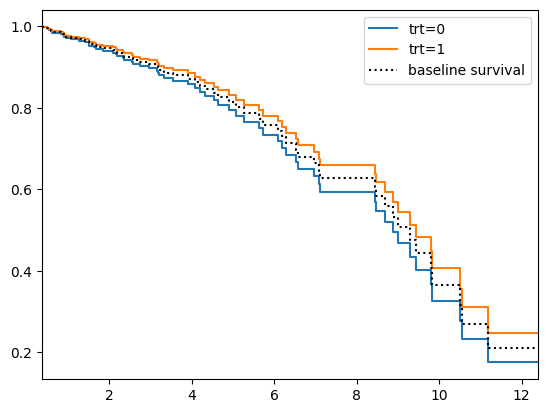

In [27]:
cph.plot_covariate_groups('trt', values=[0, 1]);

Notice how the group without treatment has a lower survival rate at all times (the x-axis is time) compared to the treatment group.

<a name='6'></a>
## 6. Hazard Ratio

Recall from the lecture videos that the Hazard Ratio between two patients was the likelihood of one patient (e.g smoker) being more at risk than the other (e.g non-smoker).
$$
\frac{\lambda_{smoker}(t)}{\lambda_{nonsmoker}(t)} = e^{\theta (X_{smoker} - X_{nonsmoker})^T}
$$

Where

$$
\lambda_{smoker}(t) = \lambda_0(t)e^{\theta X_{smoker}^T}
$$
and
$$
\lambda_{nonsmoker}(t) = \lambda_0(t)e^{\theta X_{nonsmoker}^T} \\
$$

<a name='ex-2'></a>
### Exercise 2 - hazard_ratio
In the cell below, write a function to compute the hazard ratio between two individuals given the cox model's coefficients.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints (Click to expand)</b></font>
</summary>
<p>
<ul>
    <li>use numpy.dot</li>
    <li>use nump.exp</li>
</ul>
</p>


In [32]:
# GRADED FUNCTION: hazard_ratio

def hazard_ratio(case_1, case_2, cox_params):
    '''
    Return the hazard ratio of case_1 : case_2 using
    the coefficients of the cox model.
    
    Args:
        case_1 (np.array): (1 x d) array of covariates
        case_2 (np.array): (1 x d) array of covariates
        model (np.array): (1 x d) array of cox model coefficients
    Returns:
        hazard_ratio (float): hazard ratio of case_1 : case_2
    '''
    
    ### START CODE HERE ###
    
    hr = np.exp(np.dot(cox_params,(case_1-case_2)))
    
    ### END CODE HERE ###
    
    return hr

In [33]:
# Verification of implementation
i = 1
j = 5

case_1 = one_hot_train.iloc[i, :].drop(['time', 'status'])
case_2 = one_hot_train.iloc[j, :].drop(['time', 'status'])

print("Case 1 (i=1):\n\n", case_1, "\n")
print("Case 2 (j=5):\n\n", case_2, "\n")
print("Hazard Ratio:", hazard_ratio(case_1.values, case_2.values, cph.params_.values))

Case 1 (i=1):

 trt          0.000000
age          0.069681
sex          1.000000
ascites      0.000000
hepato       1.000000
spiders      0.000000
bili         0.895363
chol         0.406085
albumin      1.008332
copper       1.846223
alk.phos     0.101665
ast          0.472367
trig         1.621764
platelet    -0.120868
protime     -0.239610
edema_0.5    0.000000
edema_1.0    0.000000
stage_2.0    0.000000
stage_3.0    1.000000
stage_4.0    0.000000
Name: 137, dtype: float64 

Case 2 (j=5):

 trt          0.000000
age         -1.424184
sex          0.000000
ascites      0.000000
hepato       0.000000
spiders      0.000000
bili        -0.531549
chol        -0.623107
albumin      1.008332
copper      -0.840144
alk.phos    -0.632331
ast         -1.458600
trig        -0.746414
platelet    -0.184759
protime      0.059579
edema_0.5    0.000000
edema_1.0    0.000000
stage_2.0    0.000000
stage_3.0    1.000000
stage_4.0    0.000000
Name: 303, dtype: float64 

Hazard Ratio: 15.029017732492221

#### Expected Output:

```
Hazard Ratio: 15.029017732492221
```

In [34]:
# Test your code!
unittests.exercise_2(hazard_ratio)

 All tests passed!


<br>

**Question:** 

Is `case_1` (i=1) or `case_2` (j=5) at greater risk? 

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Check your answer!</b></font>
</summary>
<p>
<ul>
<ul>
    <li>You should see that `case_1` is at higher risk.</li>
    <li>The hazard ratio of case 1 / case 2 is greater than 1, so case 1 had a higher hazard relative to case 2</li>
</ul>
</p>

Inspect different pairs, and see if you can figure out which patient is more at risk.

In [36]:
# EDITABLE CELL:

i = 4
case_1 = one_hot_train.iloc[i, :].drop(['time', 'status'])

j = 7
case_2 = one_hot_train.iloc[j, :].drop(['time', 'status'])

print(f"Case 1 (i={i})\n\n", case_1, "\n")
print(f"Case 2 (j={j})\n\n", case_2, "\n")
print("Hazard Ratio:", hazard_ratio(case_1.values, case_2.values, cph.params_.values))

Case 1 (i=4)

 trt          0.000000
age          0.563645
sex          0.000000
ascites      0.000000
hepato       1.000000
spiders      1.000000
bili        -0.405645
chol        -0.210436
albumin      1.514297
copper      -0.481961
alk.phos     2.173526
ast         -0.144699
trig        -0.531125
platelet    -0.450972
protime     -0.139881
edema_0.5    0.000000
edema_1.0    0.000000
stage_2.0    0.000000
stage_3.0    1.000000
stage_4.0    0.000000
Name: 1, dtype: float64 

Case 2 (j=7)

 trt          0.000000
age          0.463447
sex          0.000000
ascites      0.000000
hepato       1.000000
spiders      0.000000
bili        -0.489581
chol        -0.309875
albumin     -1.232371
copper      -0.504348
alk.phos     2.870427
ast         -0.936261
trig        -0.150229
platelet     3.190823
protime     -0.139881
edema_0.5    0.000000
edema_1.0    0.000000
stage_2.0    0.000000
stage_3.0    0.000000
stage_4.0    1.000000
Name: 38, dtype: float64 

Hazard Ratio: 0.178045000699713


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Check your answer!</b></font>
</summary>
<p>
<ul>
<ul>
    Important! The following answer only applies if you picked i = 4 and j = 7
    <li>You should see that `case_2` is at higher risk.</li>
    <li>The hazard ratio of case 1 / case 2 is less than 1, so case 2 had a higher hazard relative to case 1</li>
</ul>
</p>

<a name='7'></a>
## 7. Harrell's C-index

To evaluate how good our model is performing, we will write our own version of the C-index. Similar to the week 1 case, C-index in the survival context is the probability that, given a randomly selected pair of individuals, the one who died sooner has a higher risk score. 

However, we need to take into account censoring. Imagine a pair of patients, $A$ and $B$. 

#### Scenario 1
- A was censored at time $t_A$ 
- B died at $t_B$
- $t_A < t_B$. 

Because of censoring, we can't say whether $A$ or $B$ should have a higher risk score. 

#### Scenario 2
Now imagine that $t_A > t_B$.

- A was censored at time $t_A$ 
- B died at $t_B$
- $t_A > t_B$

Now we can definitively say that $B$ should have a higher risk score than $A$, since we know for a fact that $A$ lived longer. 

Therefore, when we compute our C-index
- We should only consider pairs where at most one person is censored
- If they are censored, then their censored time should occur *after* the other person's time of death. 

The metric we get if we use this rule is called **Harrel's C-index**.

Note that in this case, being censored at time $t$ means that the true death time was some time AFTER time $t$ and not at $t$. 
- Therefore if $t_A = t_B$ and A was censored:
    - Then $A$ actually lived longer than $B$. 
    - This will effect how you deal with ties in the exercise below!



<a name='ex-3'></a>
### Exercise 3 - harrell_c
Fill in the function below to compute Harrel's C-index.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints (Click to expand)</b></font>
</summary>
<p>
<ul>
    <li>If you get a division by zero error, consider checking how you count when a pair is permissible (in the case where one patient is censored and the other is not censored).</li>
</ul>
</p>

In [37]:
# GRADED FUNCTION: harrell_c

def harrell_c(y_true, scores, event):
    '''
    Compute Harrel C-index given true event/censoring times,
    model output, and event indicators.
    
    Args:
        y_true (array): array of true event times
        scores (array): model risk scores
        event (array): indicator, 1 if event occurred at that index, 0 for censorship
    Returns:
        result (float): C-index metric
    '''
    
    n = len(y_true)
    assert (len(scores) == n and len(event) == n)
    
    concordant = 0.0
    permissible = 0.0
    ties = 0.0
    
    result = 0.0
    
    ### START CODE HERE ###
    
    # use double for loop to go through cases
    for i in range(n):
    
        # set lower bound on j to avoid double counting
        for j in range(i + 1, n):
            
            # check if at most one is censored
            if event[i] == 1 or event[j] == 1:
                
                # check if neither are censored
                if event[i] == 1 and event[j] == 1:
                    
                    # increment permissible pairs
                    permissible += 1.0
                    
                    # check if scores are tied
                    if scores[i] == scores[j]:
                        
                        # increment ties
                        ties += 1.0
                    
                    # check for concordant
                    elif y_true[i] < y_true[j] and scores[i] > scores[j]:
                        
                        # increment concordant pairs
                        concordant += 1.0
                    
                    elif y_true[i] > y_true[j] and scores[i] < scores[j]:
                        
                        # increment concordant pairs
                        concordant += 1.0
                
                # check if one is censored
                elif event[i] != event[j]:
                    
                    # get censored index
                    censored = j 
                    uncensored = i 
                    
                    if event[i] == 0:
                        censored = i 
                        uncensored = j 
                        
                    # check if permissible
                    if y_true[uncensored] <= y_true[censored]:
                        
                        # increment permissible pairs
                        permissible += 1.0
                        
                        # check if scores are tied
                        if scores[uncensored] == scores[censored]:
                            
                            # increment ties
                            ties += 1.0
                            
                        # check if scores are concordant 
                        if scores[uncensored] > scores[censored]:
                            
                            # increment concordant pairs
                            concordant += 1.0
    
    # set result to c-index computed from number of concordant pairs,
    # number of ties, and number of permissible pairs
    result = (concordant + 0.5 * ties) / permissible
    
    ### END CODE HERE ###
    
    return result

In [38]:
# Verification of implementation
y_true_1 = [30, 12, 84, 9]    
event_1 = [1, 1, 1, 1]
scores_1 = [0.5, 0.9, 0.1, 1.0]
scores_2 = [0.9, 0.5, 1.0, 0.1]
event_3 = [1, 0, 1, 1]
scores_3 = [0.5, 0.9, 0.1, 1.0]
y_true_4 = [30, 30, 20, 20]
event_4 = [1, 0, 1, 0]
scores_4 = [10, 5, 15, 20]
y_true_5 = list(reversed([30, 30, 30, 20, 20]))
event_5 = [0, 1, 0, 1, 0]
scores_5 = list(reversed([15, 10, 5, 15, 20]))
y_true_6 = [10,10]
event_6 = [0,1]
scores_6 = [4,5]

print("Case 1\n")
print("y_true: ", y_true_1)
print("scores: ", scores_1)
print("event:  ", event_1)
print("Output: ", harrell_c(y_true_1, scores_1, event_1))

print("\nCase 2\n")
print("y_true: ", y_true_1)
print("scores: ", scores_2)
print("event:  ", event_1)
print("Output: ", harrell_c(y_true_1, scores_2, event_1))

print("\nCase 3\n")
print("y_true: ", y_true_1)
print("scores: ", scores_3)
print("event:  ", event_3)
print("Output: ", harrell_c(y_true_1, scores_3, event_3))

print("\nCase 4\n")
print("y_true: ", y_true_4)
print("scores: ", scores_4)
print("event:  ", event_4)
print("Output: ", harrell_c(y_true_4, scores_4, event_4))

print("\nCase 5\n")
print("y_true: ", y_true_5)
print("scores: ", scores_5)
print("event:  ", event_5)
print("Output: ", harrell_c(y_true_5, scores_5, event_5))

print("\nCase 6\n")
print("y_true: ", y_true_6)
print("scores: ", scores_6)
print("event:  ", event_6)
print("Output: ", harrell_c(y_true_6, scores_6, event_6), "\n")

Case 1

y_true:  [30, 12, 84, 9]
scores:  [0.5, 0.9, 0.1, 1.0]
event:   [1, 1, 1, 1]
Output:  1.0

Case 2

y_true:  [30, 12, 84, 9]
scores:  [0.9, 0.5, 1.0, 0.1]
event:   [1, 1, 1, 1]
Output:  0.0

Case 3

y_true:  [30, 12, 84, 9]
scores:  [0.5, 0.9, 0.1, 1.0]
event:   [1, 0, 1, 1]
Output:  1.0

Case 4

y_true:  [30, 30, 20, 20]
scores:  [10, 5, 15, 20]
event:   [1, 0, 1, 0]
Output:  0.75

Case 5

y_true:  [20, 20, 30, 30, 30]
scores:  [20, 15, 5, 10, 15]
event:   [0, 1, 0, 1, 0]
Output:  0.5833333333333334

Case 6

y_true:  [10, 10]
scores:  [4, 5]
event:   [0, 1]
Output:  1.0 



#### Expected Output:

```
Case 1
Output:  1.0

Case 2
Output:  0.0

Case 3
Output:  1.0

Case 4
Output:  0.75

Case 5
Output:  0.5833333333333334

Case 6
Output:  1.0 
```

In [39]:
# Test your code!
unittests.exercise_3(harrell_c)

 All tests passed!


<br>
Now use the Harrell's C-index function to evaluate the cox model on our data sets.

In [40]:
# Train
scores = cph.predict_partial_hazard(one_hot_train)
cox_train_scores = harrell_c(one_hot_train['time'].values, scores.values, one_hot_train['status'].values)
# Validation
scores = cph.predict_partial_hazard(one_hot_val)
cox_val_scores = harrell_c(one_hot_val['time'].values, scores.values, one_hot_val['status'].values)
# Test
scores = cph.predict_partial_hazard(one_hot_test)
cox_test_scores = harrell_c(one_hot_test['time'].values, scores.values, one_hot_test['status'].values)

print("Train:", cox_train_scores)
print("Val:", cox_val_scores)
print("Test:", cox_test_scores)

Train: 0.8265139116202946
Val: 0.8544776119402985
Test: 0.8478543563068921


<br>
What do these values tell us ?

---
# Submission Note

Congratulations! You've completed the final graded exercise of this assignment.

If you've successfully passed all the unit tests above, you've completed the core requirements of this assignment. Feel free to [submit](#submission) your work now. The grading process runs in the background, so it will not disrupt your progress and you can continue on with the rest of the material.

**🚨 IMPORTANT NOTE** If you have passed all tests within the notebook, but the autograder shows a system error for one or more exercises after you submit your work:

<br>
<div style="background-color: #E5E5EA; border: 1px solid #444444; color: #000000; padding: 15px; border-radius: 5px;">
    <p><strong>No feedback available for this exercise.</strong></p>
</div>
<br>

This is typically a temporary system glitch. The most common solution is to resubmit your assignment, as this often resolves the problem. Occasionally, it may be necessary to resubmit more than once. 
>
If the error persists, please reach out for support in the [DeepLearning.AI Community Forum](https://community.deeplearning.ai/c/course-q-a/ai-for-medicine/ai4m-course-2/97).

---

<a name='8'></a>
## 8. Random Survival Forests

This performed well, but you have a hunch you can squeeze out better performance by using a machine learning approach. You decide to use a Random Survival Forest. To do this, you can use the `RandomForestSRC` package in R. To call R function from Python, we'll use the `r2py` package. Run the following cell to import the necessary requirements. 


In [41]:
%load_ext rpy2.ipython
%R require(ggplot2)

from rpy2.robjects.packages import importr
# import R's "base" package
base = importr('base')

# import R's "utils" package
utils = importr('utils')

# import rpy2's package module
import rpy2.robjects.packages as rpackages

forest = rpackages.importr('randomForestSRC', lib_loc='R')

from rpy2 import robjects as ro
R = ro.r

from rpy2.robjects import pandas2ri
pandas2ri.activate()

Instead of encoding our categories as binary features, we can use the original dataframe since trees deal well with raw categorical data (can you think why this might be?).

Run the code cell below to build your forest.

In [42]:
model = forest.rfsrc(ro.Formula('Surv(time, status) ~ .'), data=df_train, ntree=300, nodedepth=5, seed=-1)

In [43]:
print(model)

                         Sample size: 154
                    Number of deaths: 64
                     Number of trees: 300
           Forest terminal node size: 15
       Average no. of terminal nodes: 6.54
No. of variables tried at each split: 5
              Total no. of variables: 17
       Resampling used to grow trees: swor
    Resample size used to grow trees: 97
                            Analysis: RSF
                              Family: surv
                      Splitting rule: logrank *random*
       Number of random split points: 10
                          Error rate: 19.07%




Finally, let's evaluate on our validation and test sets, and compare it with our Cox model.

In [44]:
result = R.predict(model, newdata=df_val)
scores = np.array(result.rx('predicted')[0])

print("Cox Model Validation Score:", cox_val_scores)
print("Survival Forest Validation Score:", harrell_c(df_val['time'].values, scores, df_val['status'].values))

Cox Model Validation Score: 0.8544776119402985
Survival Forest Validation Score: 0.8296019900497512


In [45]:
result = R.predict(model, newdata=df_test)
scores = np.array(result.rx('predicted')[0])

print("Cox Model Test Score:", cox_test_scores)
print("Survival Forest Validation Score:", harrell_c(df_test['time'].values, scores, df_test['status'].values))

Cox Model Test Score: 0.8478543563068921
Survival Forest Validation Score: 0.8621586475942783


Your random forest model should be outperforming the Cox model slightly. Let's dig deeper to see how they differ.

<a name='9'></a>
## 9. Permutation Method for Interpretation

We'll dig a bit deeper into interpretation methods for forests a bit later, but for now just know that random surival forests come with their own built in variable importance feature. The method is referred to as VIMP, and for the purpose of this section you should just know that higher absolute value of the VIMP means that the variable generally has a larger effect on the model outcome.

Run the next cell to compute and plot VIMP for the random survival forest.

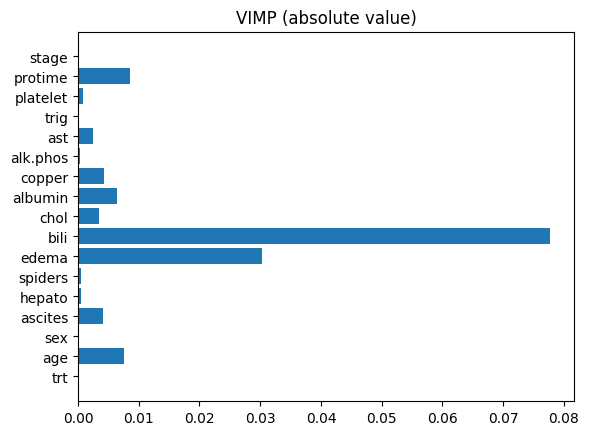

In [46]:
vimps = np.array(forest.vimp(model).rx('importance')[0])

y = np.arange(len(vimps))
plt.barh(y, np.abs(vimps))
plt.yticks(y, df_train.drop(['time', 'status'], axis=1).columns)
plt.title("VIMP (absolute value)")
plt.show()

### Question:

How does the variable importance compare to that of the Cox model? Which variable is important in both models? Which variable is important in the random survival forest but not in the Cox model? You should see that `edema` is important in both the random survival forest and the Cox model. You should also see that `bili` is important in the random survival forest but not the Cox model .

## Congratulations!

You've finished the last assignment in course 2! Take a minute to look back at the analysis you've done over the last four assignments. You've done a great job!